# 📊 Sesión 1: Herramientas de Visualización de Datos
## Notebook Python — Parte B (opcional)

**Kernel:** Python 3  
**Requisito previo:** Haber ejecutado `clase24_spark.ipynb` completo y tener los tres CSV en `C:/Curso-Scala/datos/`

> ⭐ **Este notebook es opcional.** Solo para estudiantes con conocimientos de Python.
> Si no programas en Python, no necesitas ejecutar este archivo.

---
## ⚙️ Celda 0 — Instalar bibliotecas (solo la primera vez)
Si ya las tienes instaladas puedes saltar esta celda.

In [1]:
import subprocess
resultado = subprocess.run(
    ["pip", "install", "matplotlib", "seaborn", "pandas"],
    capture_output=True, text=True
)
print(resultado.stdout[-300:] if len(resultado.stdout) > 300 else resultado.stdout)
print("✅ Bibliotecas listas")

naconda3\lib\site-packages (from pandas) (2024.1)

✅ Bibliotecas listas


---
## ⚙️ Celda 1 — Imports y función auxiliar
Ejecuta esta celda antes de cualquier ejercicio.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

%matplotlib inline

def leer_csv(carpeta):
    """Lee el archivo part-*.csv generado por Spark en la carpeta indicada."""
    archivos = glob.glob(os.path.join(carpeta, "part-*.csv"))
    if not archivos:
        raise FileNotFoundError(
            f"No se encontró ningún part-*.csv en {carpeta}\n"
            f"Asegúrate de haber ejecutado clase23_spark.ipynb primero."
        )
    return pd.read_csv(archivos[0])

print("✅ Imports listos. Puedes ejecutar los ejercicios P4, P5 y P6.")

✅ Imports listos. Puedes ejecutar los ejercicios P4, P5 y P6.


---
## ⭐ P4 — Gráfico de barras: ventas por categoría

**Origen de datos:** CSV generado en P1 del notebook Scala  
**Técnica:** `matplotlib` — `ax.bar()`

Datos cargados:
    categoria  total_ventas  num_transacciones  precio_medio
0  Tecnología       18980.0                 20         490.5
1     Oficina        4260.0                 10         147.0


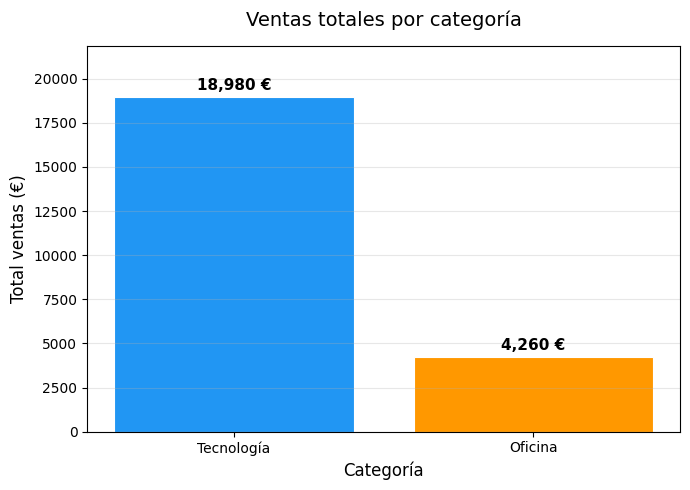

✅ Gráfico P4 generado


In [3]:
df = leer_csv("C:/Curso-Scala/datos/viz_por_categoria")
print("Datos cargados:")
print(df)

fig, ax = plt.subplots(figsize=(7, 5))
colores = ["#2196F3", "#FF9800"]
bars = ax.bar(df["categoria"], df["total_ventas"], color=colores,
              edgecolor="white", linewidth=0.8)

# Etiquetas de valor encima de cada barra
for bar, valor in zip(bars, df["total_ventas"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{valor:,.0f} €",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Ventas totales por categoría", fontsize=14, pad=15)
ax.set_xlabel("Categoría", fontsize=12)
ax.set_ylabel("Total ventas (€)", fontsize=12)
ax.set_ylim(0, df["total_ventas"].max() * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Gráfico P4 generado")

---
## ⭐ P5 — Gráfico de líneas: evolución temporal

**Origen de datos:** CSV generado en P2 del notebook Scala  
**Técnica:** `matplotlib` — `ax.plot()` con área rellena

Primeras filas:
        fecha  total_dia
0  2026-04-01     2880.0
1  2026-04-02     1300.0
2  2026-04-03      660.0
3  2026-04-04     1440.0
4  2026-04-05     1920.0


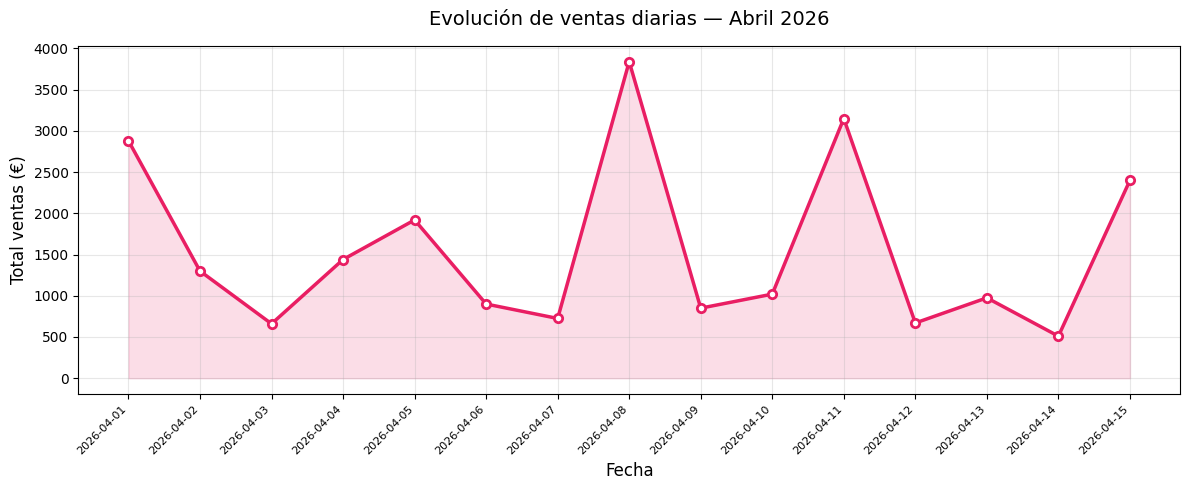

✅ Gráfico P5 generado


In [4]:
df = leer_csv("C:/Curso-Scala/datos/viz_por_fecha")
df = df.sort_values("fecha").reset_index(drop=True)
print("Primeras filas:")
print(df.head())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    range(len(df)), df["total_dia"],
    marker="o", color="#E91E63", linewidth=2.5,
    markersize=6, markerfacecolor="white", markeredgewidth=2
)
ax.fill_between(range(len(df)), df["total_dia"], alpha=0.15, color="#E91E63")

ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["fecha"], rotation=45, ha="right", fontsize=8)
ax.set_title("Evolución de ventas diarias — Abril 2026", fontsize=14, pad=15)
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Total ventas (€)", fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Gráfico P5 generado")

---
## ⭐ P6 — Dashboard: 3 gráficos combinados

**Origen de datos:** Los tres CSV generados en P1, P2 y P3 del notebook Scala  
**Técnica:** `plt.subplots(1, 3)` — combinar múltiples gráficos en una figura  
**Salida:** figura mostrada en el notebook + PNG guardado en `C:/Curso-Scala/datos/`

C:\Users\rodba\AppData\Local\Temp\ipykernel_27652\4182303439.py:37: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rodba\AppData\Local\Temp\ipykernel_27652\4182303439.py:39: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(ruta_png, dpi=150, bbox_inches="tight")
C:\Users\rodba\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


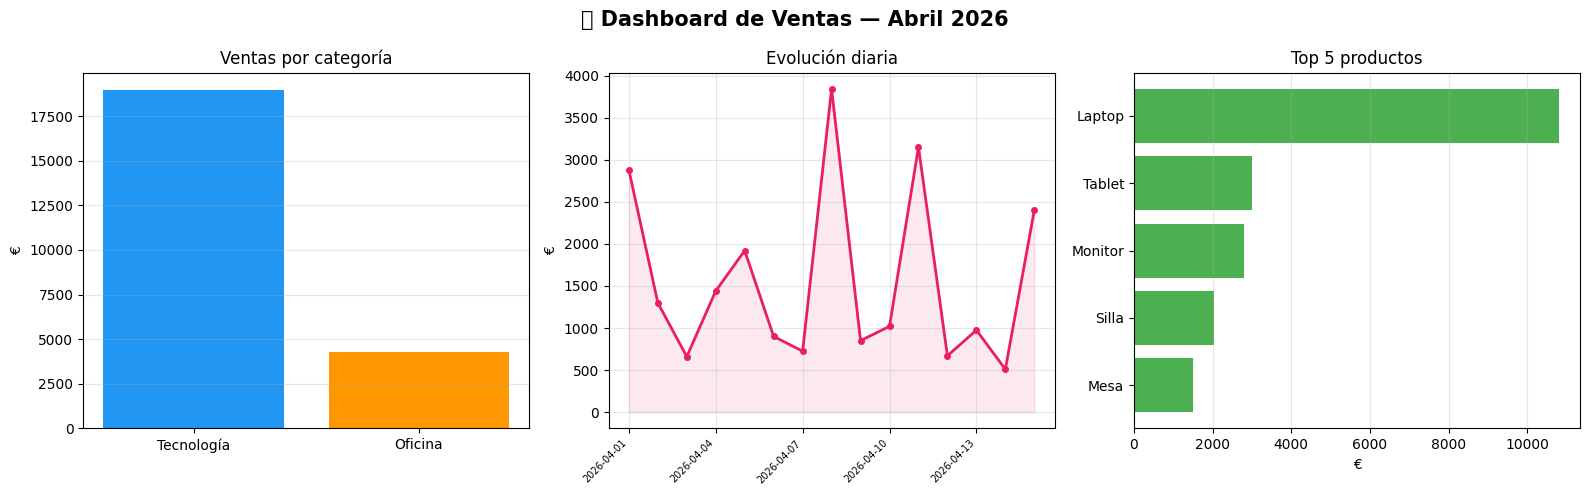

✅ Dashboard guardado en C:/Curso-Scala/datos/dashboard_abril_2026.png


In [5]:
df_cat   = leer_csv("C:/Curso-Scala/datos/viz_por_categoria")
df_fecha = leer_csv("C:/Curso-Scala/datos/viz_por_fecha").sort_values("fecha")
df_prod  = leer_csv("C:/Curso-Scala/datos/viz_top_productos").sort_values("total")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("📊 Dashboard de Ventas — Abril 2026", fontsize=15, fontweight="bold")

# ── Gráfico 1: barras por categoría ──────────────────────────────────────
axes[0].bar(df_cat["categoria"], df_cat["total_ventas"],
            color=["#2196F3", "#FF9800"])
axes[0].set_title("Ventas por categoría")
axes[0].set_ylabel("€")
axes[0].grid(axis="y", alpha=0.3)

# ── Gráfico 2: evolución temporal ────────────────────────────────────────
axes[1].plot(
    range(len(df_fecha)), df_fecha["total_dia"],
    marker="o", color="#E91E63", linewidth=2, markersize=4
)
axes[1].fill_between(
    range(len(df_fecha)), df_fecha["total_dia"], alpha=0.1, color="#E91E63"
)
axes[1].set_title("Evolución diaria")
axes[1].set_ylabel("€")
axes[1].set_xticks(range(0, len(df_fecha), 3))
axes[1].set_xticklabels(
    df_fecha["fecha"].iloc[::3], rotation=45, ha="right", fontsize=7
)
axes[1].grid(alpha=0.3)

# ── Gráfico 3: top 5 productos (barras horizontales) ─────────────────────
axes[2].barh(df_prod["producto"], df_prod["total"], color="#4CAF50")
axes[2].set_title("Top 5 productos")
axes[2].set_xlabel("€")
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
ruta_png = "C:/Curso-Scala/datos/dashboard_abril_2026.png"
plt.savefig(ruta_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Dashboard guardado en {ruta_png}")

---
## 🏁 Fin de la Parte B

Si has completado P4, P5 y P6 has generado:
- Un gráfico de barras por categoría
- Un gráfico de líneas de evolución temporal
- Un dashboard con 3 gráficos combinados guardado como PNG

El PNG está en `C:\Curso-Scala\datos\dashboard_abril_2026.png`

---